In [31]:
!pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost -q
print("pip 설치 완료!")

pip 설치 완료!



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
!pip install -U imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [34]:
# ============================================================
# 데이터 소개
# ============================================================

# - 공정(Process) 데이터
#     - Shot ID: 주조 샷 고유 식별자
#     - Injection Speed: 용탕 주입 속도 (m/s)
#     - Die Temperature: 금형 온도 (°C)
#     - Casting Pressure: 주조 압력 (bar)
#     - Cooling Time: 냉각 시간 (s)

# - 센서(Sensor) 데이터
#     - Mold Temp Sensor: 금형 내 센서 온도 (°C)
#     - Hydraulic Pressure: 유압 압력 (bar)
#     - Vibration Sensor: 진동값 (Hz)
#     - Flow Rate Sensor: 유량 (L/min)

# - 불량(Defects) 데이터
#     - Defect Type: 발생한 불량 유형 (미성형, 박리, 기공, 평탄, 개재물 등)
#     - Defect Status: 양품(0) / 불량(1) 여부

## 데이터 로드

#### header를 사용하여 0행과 1행을 머리글 행으로 하는 멀티컬럼 생성

In [57]:
df = pd.read_csv('./data/DieCasting_Quality_Raw_Data.csv',header=[0,1])
df_origin = df.copy()
print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nArticles: {df.shape}")

print("\n[Data Info]")
df.info()

데이터 로드 완료!

Articles: (7535, 57)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float64
 12 

## 샘플 데이터 확인


In [36]:
print("\n" + "="*60)
print("샘플 데이터")
print("="*60)
display(df.head())


샘플 데이터


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                        \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
0               214           0.008                 10             258   
1               217           0.008                 11             257   
2               214           0.008                 11             257   
3               217           0.008                 11             257   
4               217           0.008                 12             257   

                                                                           \
  Cycle_Time  Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7               0.044             1037        7.8          0.7   
1       20.7               0.044             1052        7.8          0.7   
2       20.8               0.041             1037        7.8          0.7   
3       20.7               0.043             1051        7.8          0.7   
4       20.7               0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0        

## 기초 통계량 확인

In [59]:
print("\n" + "="*60)
print("기초 통계")
print("="*60)
display(df.drop(columns=[
        ('Process', 'id'),
        ('Process', 'Product_Type'),
        ('Process', 'Shot')
    ]).describe())


기초 통계


Process                                                            \
        Velocity_1   Velocity_2   Velocity_3 High_Velocity Cylinder_Pressure   
count  7535.000000  7535.000000  7535.000000   7535.000000       7535.000000   
mean      0.148219     0.168801     0.191193      2.319210        239.655607   
std       0.007134     0.004720     0.011563      0.222041         23.305451   
min       0.134000     0.158000     0.172000      0.000000        107.000000   
25%       0.142000     0.166000     0.181000      2.134000        217.000000   
50%       0.144000     0.168000     0.188000      2.161000        239.000000   
75%       0.156000     0.170000     0.202000      2.523000        265.000000   
max       0.180000     0.212000     0.234000      2.744000        266.000000   

                                                                       \
      Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    Cycle_Time   
count     7535.000000        7535.000000     7535.000000  7535.000000   
mean         0.009596          14.309622      306.433311    27.735979   
std          0.002148           3.286284       57.274965     8.716156   
min          0.000000           0.000000      238.000000    20.200000   
25%          0.008000          11.000000      255.000000    20.900000   
50%          0.009000          13.000000      258.000000    22.600000   
75%          0.012000          17.000000      372.000000    35.900000   
max          0.021000          24.000000      388.000000   218.600000   

                                                                      \
       Pressure_Rise_Time Casting_Pressure   Spray_Time Spray_1_Time   
count         7535.000000      7535.000000  7535.000000  7535.000000   
mean             0.039348       856.944127     9.815979     1.409104   
std              0.003945       234.815490     1.842438     0.557060   
min              0.000000       516.000000     7.000000     0.700000   
25%              0.036000       596.000000     8.000000     0.800000   
50%              0.041000      1037.000000     9.700000     1.200000   
75%              0.043000      1053.000000    12.100000     2.000000   
max              0.046000      1164.000000    13.100000     2.500000   

                                 Sensor                                \
      Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
count  7535.000000          7535.000000  7535.000000           7535.0   
mean      1.396045           680.652661     6.109595              3.0   
std       0.716170            25.288666     0.647906              0.0   
min       0.700000           635.300000     4.600000              3.0   
25%       0.800000           656.700000     5.700000              3.0   
50%       0.800000           680.300000     6.200000              3.0   
75%       2.000000           703.100000     6.600000              3.0   
max       3.000000           730.000000     7.100000              3.0   

                                                                       \
      Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
count           7535.0  7535.000000           7535.0           7535.0   
mean               9.0    26.830126             10.0             50.0   
std                0.0     0.525149              0.0              0.0   
min                9.0    25.900000             10.0             50.0   
25%                9.0    26.500000             10.0             50.0   
50%                9.0    26.800000             10.0             50.0   
75%                9.0    27.200000             10.0             50.0   
max                9.0    28.100000             10.0             50.0   

                                                                       \
      Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
count      7535.000000  7445.000000           7445.0           7445.0   
mean          2.701155    32.829684             18.0             22.0   
std 

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float64
 12  (Process,  Pressure_Rise_Time)  7535 non-null

# 데이터 전처리

## 데이터 정제

### 중복 데이터 확인

In [39]:
print("\n" + "="*60)
print("중복 데이터 확인")
print("="*60)

# 전체 행 중복 확인
print("\n[전체 행 기준 중복]")
print(f"diecasting 중복: {df.duplicated().sum():,}건")


중복 데이터 확인

[전체 행 기준 중복]
diecasting 중복: 0건


## 결측치 처리

In [43]:
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

missing_df = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측비율(%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df) > 0:
    print("\n[결측치 현황]")
    display(missing_df)
else:
    print("\n결측치 없음")


결측치 확인

[결측치 현황]


결측수  결측비율(%)
Sensor Factory_Temp           90     1.19
       Factory_Temp_Min       90     1.19
       Factory_Temp_Max       90     1.19
       Factory_Humidity       90     1.19
       Factory_Humidity_Min   90     1.19
       Factory_Humidity_Max   90     1.19

Factory_Temp 공장 온도 측정값 float64

Factory_Humidity 공장 습도 측정값 float64

## 히스토그램 생성

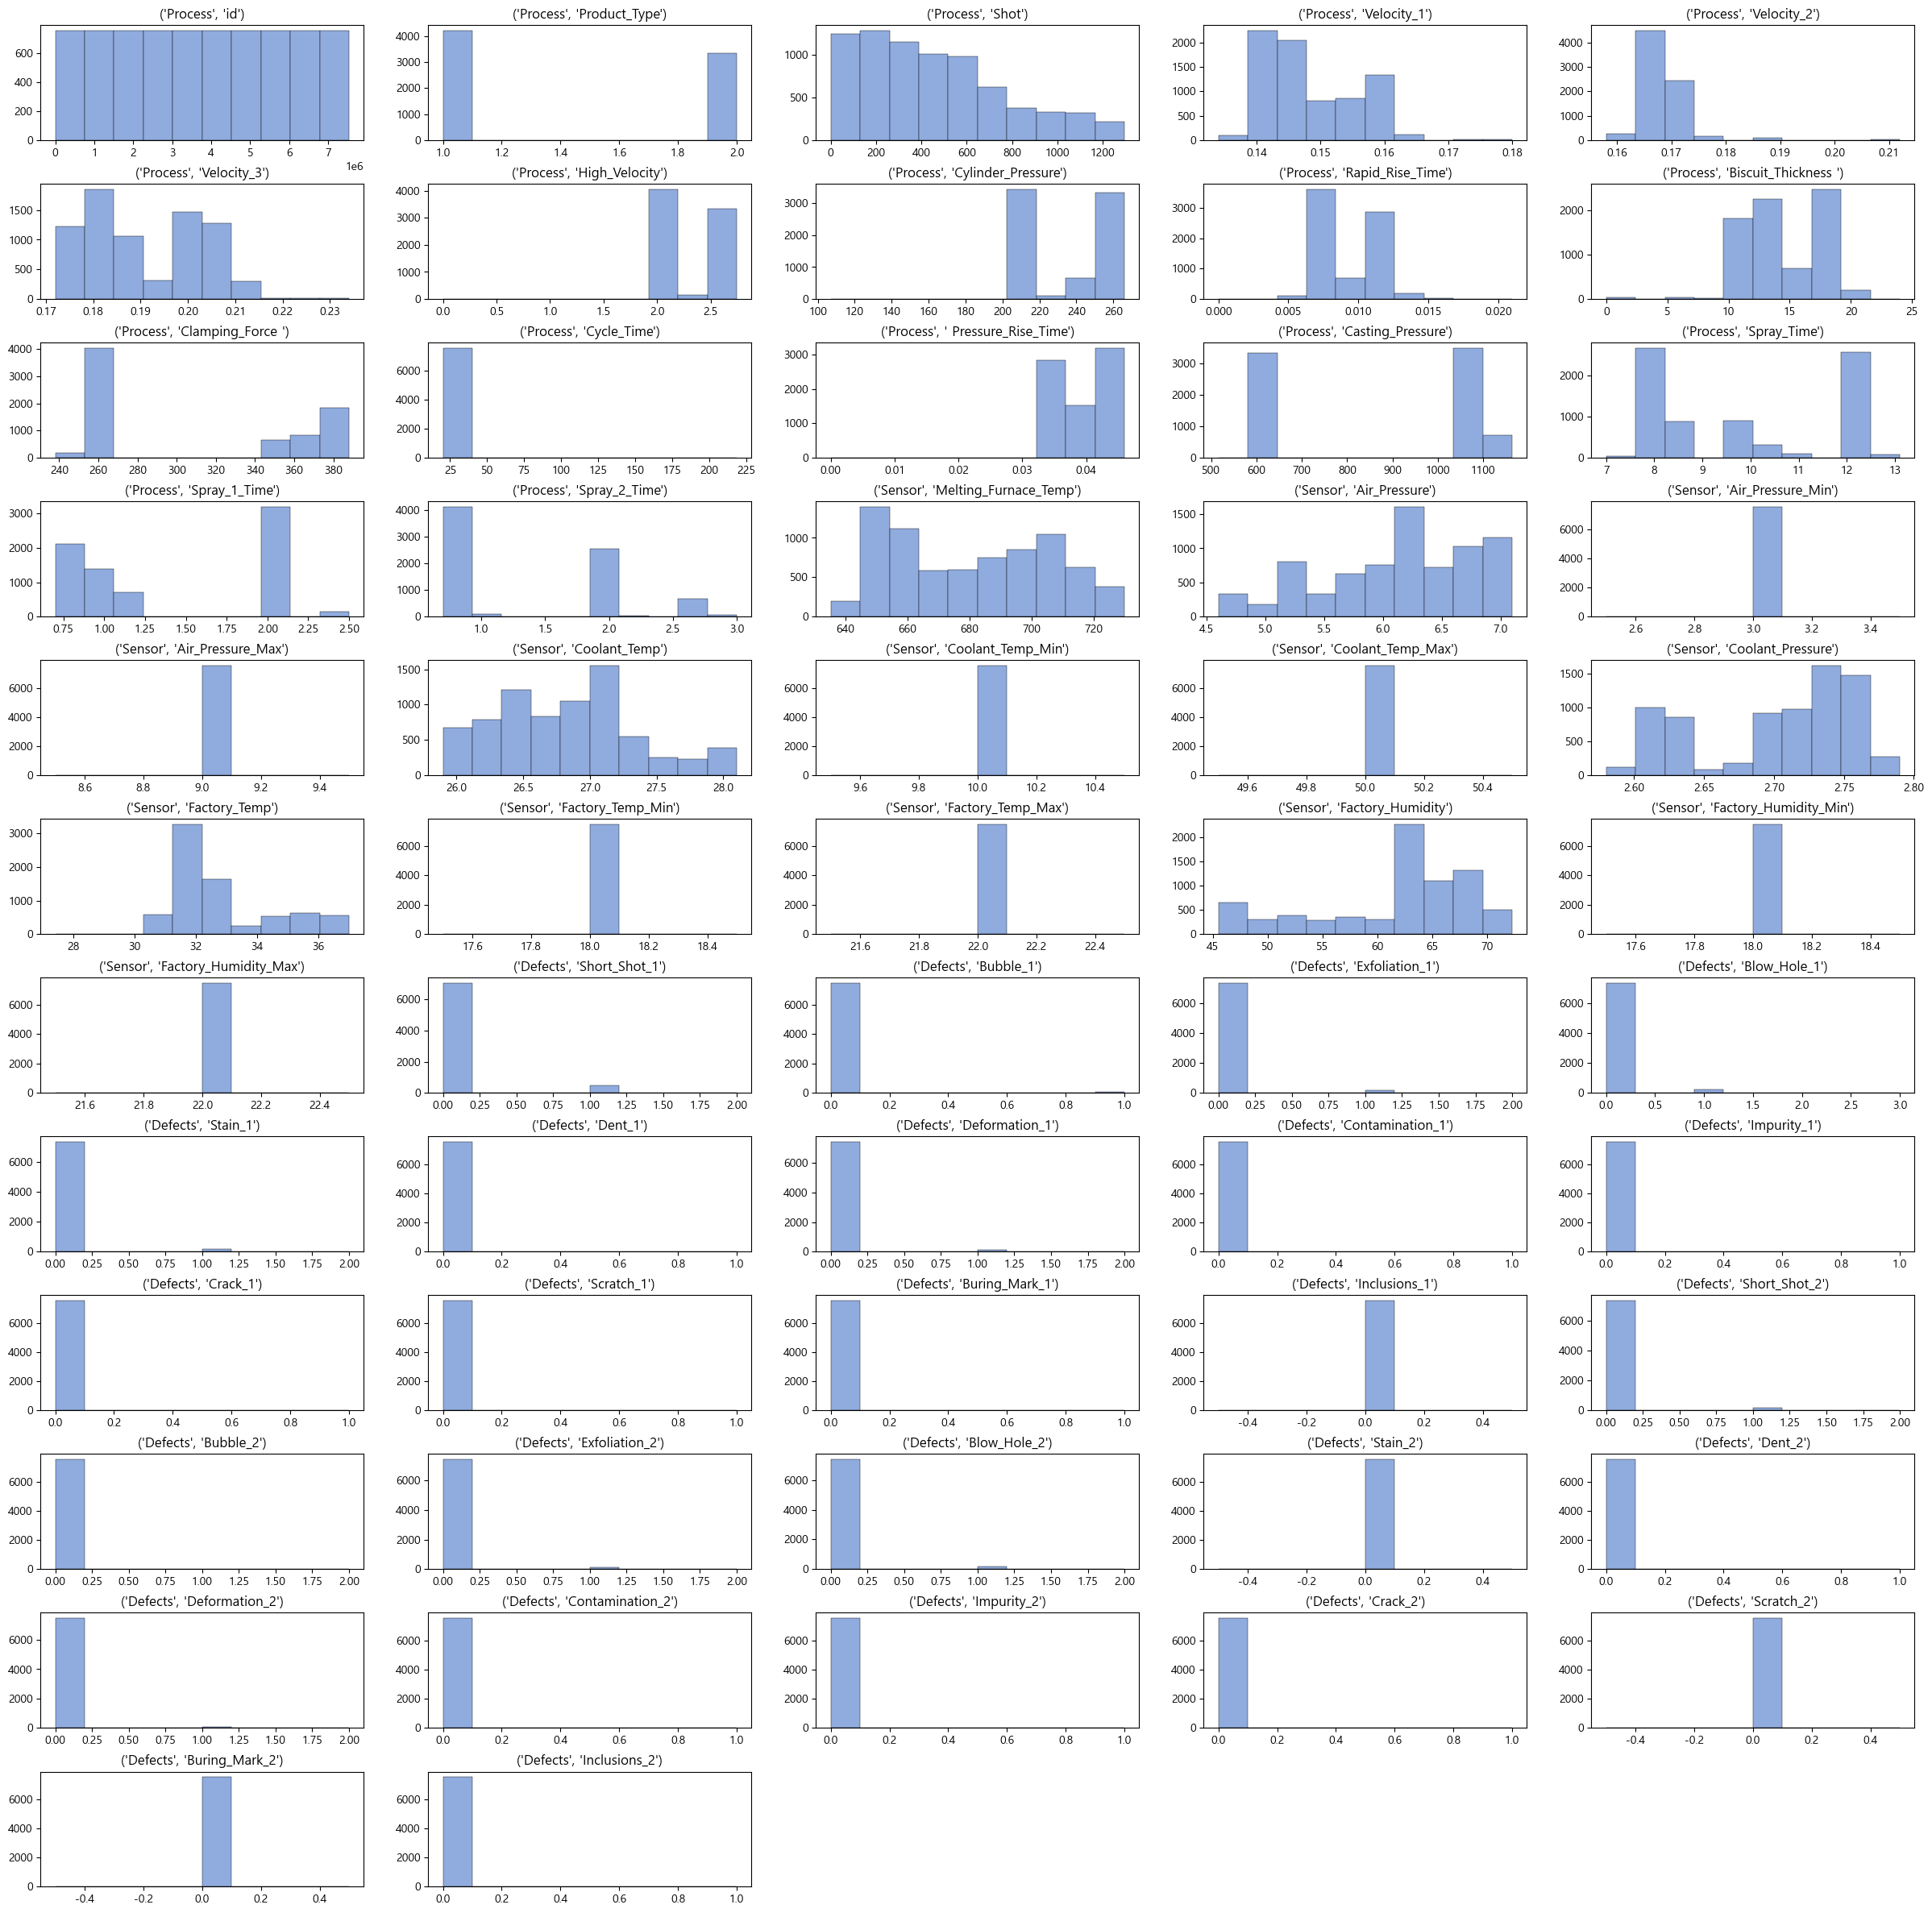

In [47]:
plt.figure(figsize=(30,30))
plt.subplots_adjust(hspace=0.38)
# 각 변수의 막대그래프 개수
for index,value in enumerate(df):
 sub=plt.subplot(12,5,index+1)
 sub.hist(df[value],facecolor=(144/255,171/255,221/255),
	 	 	 linewidth=.3,edgecolor='black')
 plt.title(value)

## 불량(1) 개수 확인하기

In [53]:
defect_df = df['Defects']
(defect_df == 1).sum().sort_values(ascending=False)


Short_Shot_1       482
Blow_Hole_1        199
Short_Shot_2       178
Exfoliation_1      171
Stain_1            169
Blow_Hole_2        149
Exfoliation_2      128
Deformation_1      107
Bubble_1            72
Deformation_2       63
Contamination_2      8
Dent_1               7
Bubble_2             5
Impurity_2           5
Buring_Mark_1        5
Dent_2               4
Contamination_1      4
Impurity_1           2
Scratch_1            2
Crack_2              2
Crack_1              1
Inclusions_2         1
Stain_2              0
Inclusions_1         0
Scratch_2            0
Buring_Mark_2        0
dtype: int64

### Defects가 0이나 1이 아닌 경우(=2)

In [1]:
defect2 = defect_df.columns[(defect_df == 2).any()]
defect2

NameError: name 'defect_df' is not defined